# Text Modelling
PCA, LDA, Sentiment, and Word2Vec models for the US Airlines Twitter corpus.

## Importing Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.manifold import TSNE
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from gensim.models import Word2Vec

nltk.download('vader_lexicon', quiet=True)
sns.set_theme(style='ticks')

## Load Tables

In [2]:
TOKENS = pd.read_csv(
    'TOKENS.csv',
    index_col=['airline_num', 'day_num', 'tweet_num', 'sent_num', 'token_num']
)

LIB = pd.read_csv(
    'LIB.csv',
    index_col='airline_num'
)

VOCAB = pd.read_csv(
    'VOCAB.csv',
    index_col='term_str'
)

BOW = pd.read_csv(
    'BOW.csv',
    index_col=['airline_num', 'day_num', 'tweet_num', 'term_str']
)

DTM = pd.read_parquet('DTM.parquet')

TFIDF = pd.read_parquet('TFIDF.parquet')

TFIDF_L2 = pd.read_parquet('TFIDF_NORM.parquet')

airline_raw = pd.read_parquet('airline_clean.parquet')

airline_raw['airline_num'] = airline_raw['airline'].astype('category').cat.codes
airline_raw['day_num'] = airline_raw['day_of_week']
airline_raw['tweet_num'] = airline_raw.groupby(['airline_num', 'day_num']).cumcount()

airline_map = LIB['airline'].to_dict()

DOC_LEVEL = ['airline_num', 'day_num', 'tweet_num']

MIN_FREQ = 5
N_TOPICS = 10

POS_FILTER = ['NOUN', 'VERB', 'ADJ', 'ADV']

SIG_VOCAB = VOCAB[
    (~VOCAB['stop']) &
    (VOCAB['max_pos_group'].isin(POS_FILTER)) &
    (VOCAB['n'] >= MIN_FREQ) &
    (VOCAB.index.str.match(r'^[a-z][a-z\-]+$'))
].copy()


## PCA

In [35]:
N_PCA_FEATURES = 200
top_terms = SIG_VOCAB.sort_values('dfidf', ascending=False).head(N_PCA_FEATURES).index

X_pca = TFIDF_L2[top_terms].fillna(0)

pca = PCA(n_components=20, random_state=42)
pca_coords = pca.fit_transform(X_pca)

PCA_DCM = pd.DataFrame(
    pca_coords,
    index=X_pca.index,
    columns=[f'PC{i+1}' for i in range(20)]
)
PCA_LOADINGS = pd.DataFrame(
    pca.components_.T,
    index=top_terms,
    columns=[f'PC{i+1}' for i in range(20)]
)


In [4]:
PCA_DCM.to_csv('PCA_DCM.csv')
PCA_LOADINGS.to_csv('PCA_LOADINGS.csv')
print('saved')

saved


### PCA Visualization 1: PC1 vs PC2

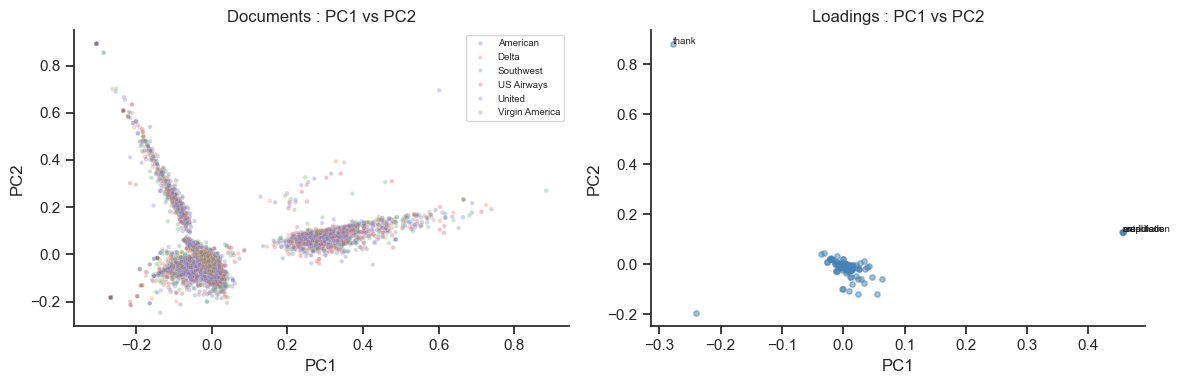

In [5]:
plot_df = PCA_DCM[['PC1','PC2']].reset_index()
plot_df['airline'] = plot_df['airline_num'].map(airline_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='airline',
                alpha=0.3, s=10, ax=axes[0])
axes[0].set_title('Documents : PC1 vs PC2')
axes[0].legend(fontsize=7)

load_df = PCA_LOADINGS[['PC1','PC2']].copy()
axes[1].scatter(load_df['PC1'], load_df['PC2'], alpha=0.5, s=15, color='steelblue')
for term in load_df['PC1'].abs().nlargest(5).index:
    axes[1].annotate(term, (load_df.loc[term,'PC1'], load_df.loc[term,'PC2']), fontsize=7)
axes[1].set_title('Loadings : PC1 vs PC2')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
sns.despine()
plt.savefig('PCA_viz1.png', dpi=120, bbox_inches='tight')
plt.show()

The left plot shows how documents (tweets) are distributed across the first two principal components (PC1 and PC2), colored by airline. The heavy overlap across airlines suggests that most airlines use similar vocabulary overall, with no very strong separation between them in this reduced space. A few small shifts or clusters indicate mild differences in language patterns, but nothing sharply distinct.

The right plot shows the word loadings. Words positioned far from the center are the ones that most influence the principal components. This means PC1 and PC2 are mainly driven by a small set of strongly weighted terms, while most words contribute only weakly. The clustering of loadings near the origin suggests that overall variation is concentrated in a limited number of meaningful terms rather than being spread evenly across the vocabulary.

### PCA Visualization 2: PC3 vs PC4

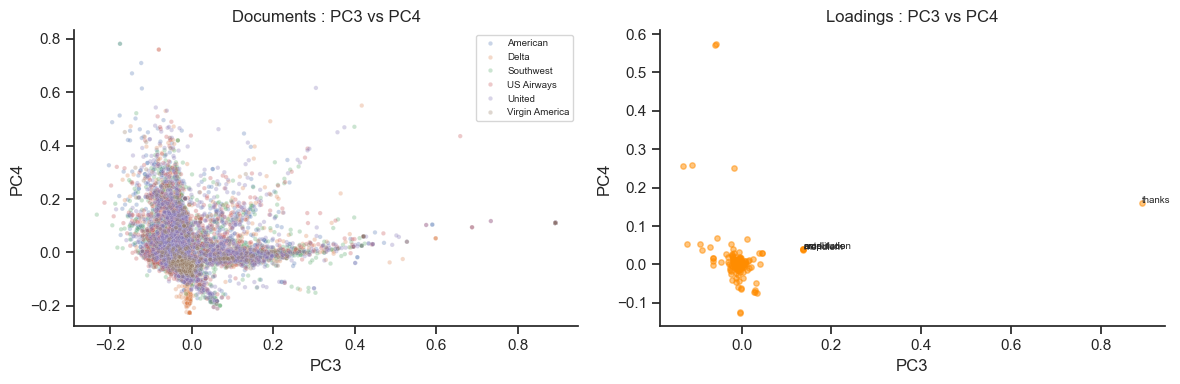

In [6]:
plot_df2 = PCA_DCM[['PC3','PC4']].reset_index()
plot_df2['airline'] = plot_df2['airline_num'].map(airline_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=plot_df2, x='PC3', y='PC4', hue='airline',
                alpha=0.3, s=10, ax=axes[0])
axes[0].set_title('Documents : PC3 vs PC4')
axes[0].legend(fontsize=7)

load_df2 = PCA_LOADINGS[['PC3','PC4']].copy()
axes[1].scatter(load_df2['PC3'], load_df2['PC4'], alpha=0.5, s=15, color='darkorange')
for term in load_df2['PC3'].abs().nlargest(5).index:
    axes[1].annotate(term, (load_df2.loc[term,'PC3'], load_df2.loc[term,'PC4']), fontsize=7)
axes[1].set_title('Loadings : PC3 vs PC4')
axes[1].set_xlabel('PC3'); axes[1].set_ylabel('PC4')

plt.tight_layout()
sns.despine()
plt.savefig('PCA_viz2.png', dpi=120, bbox_inches='tight')
plt.show()

The left plot (PC3 vs PC4) again shows that tweets from different airlines are heavily mixed together. There is no clear separation between airlines, which suggests that these components are capturing more general language variation rather than airline-specific differences. Most points are clustered near the center, with a few scattered outliers.

The right plot (loadings) shows that only a few words strongly influence PC3 and PC4, while most words stay close to zero. This indicates that these components are driven by a small number of specific terms rather than broad patterns across the vocabulary. The presence of a few far-out points suggests certain words have a strong but limited effect on these dimensions.

## LDA

In [8]:
lda_vocab = VOCAB[
    (VOCAB['max_pos_group'].isin(['NOUN','VERB'])) &
    (VOCAB['n'] >= MIN_FREQ) &
    (~VOCAB['stop']) &
    (VOCAB.index.str.match(r'^[a-z][a-z\-]+$'))
].index
lda_cols = DTM.columns.intersection(lda_vocab)
DTM_LDA  = DTM[lda_cols]

lda = LatentDirichletAllocation(
    n_components=N_TOPICS, random_state=42,
    max_iter=30, learning_method='batch'
)
theta_vals = lda.fit_transform(DTM_LDA)

THETA = pd.DataFrame(theta_vals, index=DTM_LDA.index,
                     columns=[f'T{i:02d}' for i in range(N_TOPICS)])
PHI = pd.DataFrame(lda.components_,
                     index=[f'T{i:02d}' for i in range(N_TOPICS)],
                     columns=lda_cols)

print(f'THETA: {THETA.shape}  (docs x topics)')
print(f'PHI: {PHI.shape}  (topics x terms)')
print('Top 5 words per topic')
for t in PHI.index:
    words = PHI.loc[t].nlargest(5).index.tolist()
    print(f'{t}:{words}')

THETA: (14556, 10)  (docs x topics)
PHI: (10, 1694)  (topics x terms)
Top 5 words per topic
T00:['meridiem', 'amplitude', 'ante', 'modulation', 'time']
T01:['information', 'technology', 'time', 'make', 'think']
T02:['flight', 'time', 'cancel', 'delay', 'miss']
T03:['time', 'book', 'hell', 'flight', 'problem']
T04:['thank', 'time', 'message', 'airport', 'send']
T05:['service', 'customer', 'hell', 'fly', 'airline']
T06:['wait', 'see', 'note', 'author', 'hour']
T07:['time', 'miss', 'bag', 'want', 'luggage']
T08:['time', 'get', 'help', 'call', 'hold']
T09:['miss', 'time', 'thanks', 'flight', 'use']


Most topics reflect issues like flight delays, cancellations, missed flights, baggage problems, and customer service interactions such as calls, help requests, and complaints. However, the topics are not very clearly separated because common words like “time” appear in almost all topics, making them overlap. Overall, the model is able to pick up the main theme of airline service issues, but the topic quality is slightly affected by frequent generic words.

In [33]:
DTM_LDA.to_csv('DTM_LDA.csv')
THETA.to_csv('THETA.csv')
PHI.to_csv('PHI.csv')
print('saved')

saved


### LDA + PCA Visualization

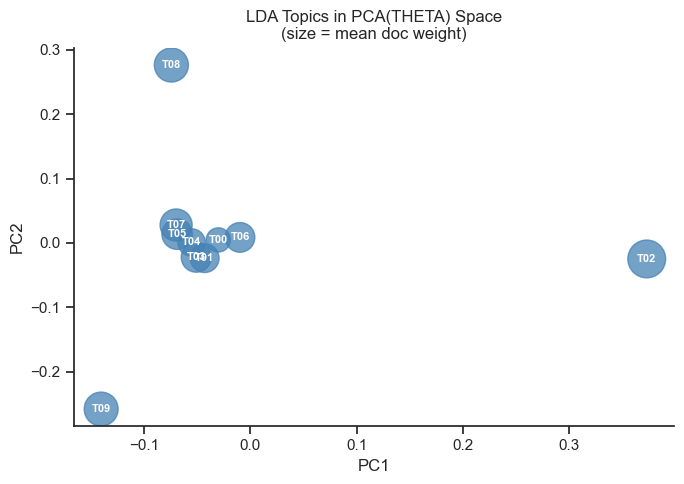

In [10]:
pca_theta = PCA(n_components=2, random_state=42)
theta_2d  = pca_theta.fit_transform(THETA.values)

topic_list = []
for i, t in enumerate([f'T{j:02d}' for j in range(N_TOPICS)]):
    w = THETA[t].values
    topic_list.append({
        'topic': t,
        'PC1': np.average(theta_2d[:, 0], weights=w),
        'PC2': np.average(theta_2d[:, 1], weights=w),
        'mean_weight': w.mean()
    })
topic_df = pd.DataFrame(topic_list)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(topic_df['PC1'], topic_df['PC2'],
           s=topic_df['mean_weight'] * 5000, color='steelblue', alpha=0.75)
for _, row in topic_df.iterrows():
    ax.annotate(row['topic'], (row['PC1'], row['PC2']),
                fontsize=8, ha='center', va='center', fontweight='bold', color='white')
ax.set_title('LDA Topics in PCA(THETA) Space\n(size = mean doc weight)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
sns.despine()
plt.tight_layout()
plt.savefig('LDA_PCA_viz.png', dpi=120, bbox_inches='tight')
plt.show()

This plot shows the LDA topics projected into a 2D PCA space, where distance between points indicates how different the topics are. Most topics (like T00, T01, T03, T04, T05, T06, T07) are clustered close together near the center, meaning they are quite similar and not very well separated. However, T02 is clearly separated on the right side, suggesting it represents a distinct theme, likely flight delays or cancellations. T08 is also somewhat isolated at the top, indicating a more unique topic, possibly related to customer support or help-related issues. T09 is separated in the bottom-left, showing another distinct pattern. Overall, a few topics are well-defined, but many are overlapping, which suggests moderate topic quality with some redundancy.

## Sentiment Analysis

In [22]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
vader_lex = sia.lexicon

VOCAB_SENT = VOCAB.loc[VOCAB.index.intersection(vader_lex.keys())].copy()

VOCAB_SENT['valence'] = VOCAB_SENT.index.map(vader_lex)

print(f'VOCAB_SENT: {len(VOCAB_SENT):,} terms with VADER valence scores')

print('\nMost positive:')
print(VOCAB_SENT.sort_values('valence', ascending=False)[['n','valence']].head().to_string())

print('\nMost negative:')
print(VOCAB_SENT.sort_values('valence')[['n','valence']].head().to_string())

VOCAB_SENT: 1,100 terms with VADER valence scores

Most positive:
              n  valence
term_str                
sweetheart    3      3.3
paradise      1      3.2
best        193      3.2
love        312      3.2
perfectly     2      3.2

Most negative:
             n  valence
term_str               
murder       3     -3.7
kill        20     -3.7
fu           2     -3.7
hell      1523     -3.6
suicide      6     -3.5


In [23]:
VOCAB_SENT.to_csv('VOCAB_SENT.csv')
print('saved')

saved


In [24]:
tok_sent = (
    TOKENS.reset_index()
    .query("term_str in @VOCAB_SENT.index")
)

BOW_SENT = (
    tok_sent
    .groupby(DOC_LEVEL + ['term_str'])
    .size()
    .rename('n')
    .reset_index()
)

BOW_SENT['valence'] = BOW_SENT['term_str'].map(VOCAB_SENT['valence'])

BOW_SENT = BOW_SENT.set_index(DOC_LEVEL + ['term_str'])

print(f'BOW_SENT: {len(BOW_SENT):,} (doc, term) pairs')
BOW_SENT.head()

BOW_SENT: 28,707 (doc, term) pairs


n  valence
airline_num day_num tweet_num term_str             
0           0       0         cancelled  1     -1.0
                              drop       1     -1.1
                              fyi        1      0.8
                              help       1      1.7
                    1         feeling    1      0.5

In [25]:
BOW_SENT.to_csv('BOW_SENT.csv')
print('saved')

saved


In [26]:
DOC_SENT = (
    BOW_SENT.reset_index()
    .groupby(DOC_LEVEL)
    .apply(lambda g: np.average(g['valence'], weights=g['n']))
    .rename('mean_sentiment')
    .reset_index()
)

print(f'DOC_SENT: {len(DOC_SENT):,} documents')
print(DOC_SENT['mean_sentiment'].describe().round(3).to_string())

DOC_SENT: 12,533 documents
count    12533.000
mean         0.093
std          1.441
min         -3.700
25%         -1.000
50%          0.100
75%          1.300
max          3.250


C:\Users\karina mehta\AppData\Local\Temp\ipykernel_9828\821947119.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['valence'], weights=g['n']))


In [27]:
DOC_SENT.to_csv('DOC_SENT.csv', index=False)
print('saved')

saved


### Sentiment Plot

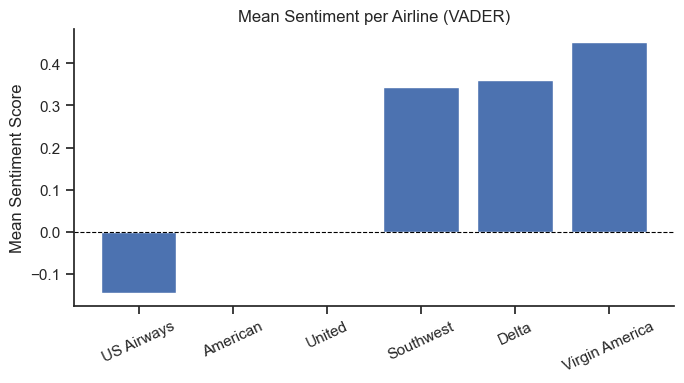

In [29]:
doc_meta = airline_raw[['airline_num','day_num','tweet_num',
                         'airline','day_name']].drop_duplicates()

sent_full = DOC_SENT.merge(
    doc_meta,
    on=['airline_num','day_num','tweet_num'],
    how='left'
)

airline_sent = sent_full.groupby('airline')['mean_sentiment'].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(airline_sent.index, airline_sent.values)

ax.axhline(0, color='black', lw=0.8, ls='--')

ax.set_title('Mean Sentiment per Airline (VADER)')
ax.set_ylabel('Mean Sentiment Score')
ax.tick_params(axis='x', rotation=25)

sns.despine()
plt.tight_layout()
plt.savefig('sentiment_plot.png', dpi=120, bbox_inches='tight')
plt.show()

This plot shows the average VADER sentiment score for each airline based on tweets. Values above zero indicate generally positive sentiment, while values below zero indicate negative sentiment. From the comparison, we can see which airlines receive more positive or negative feedback overall in customer discussions. We can see US airways got the most negative feedback while Virgin America got the most positive feedback. This sentiment analysis gives us a good idea of which airline to trust less while travelling something which is very important to customers 

## Word2Vec

In [18]:
sentences = (
    TOKENS.reset_index()
    .groupby(['airline_num','day_num','tweet_num','sent_num'])['token_str']
    .apply(list)
    .tolist()
)

w2v = Word2Vec(
    sentences, vector_size=100, window=5,
    min_count=5, workers=4, seed=42, epochs=15
)

VOCAB_W2V = pd.DataFrame(
    {word: w2v.wv[word] for word in w2v.wv.index_to_key}
).T
VOCAB_W2V.index.name = 'term_str'
VOCAB_W2V.columns = [f'D{i:03d}' for i in range(w2v.vector_size)]

print(f'VOCAB_W2V: {VOCAB_W2V.shape}  ({len(w2v.wv.index_to_key):,} terms x {w2v.vector_size} dims)')
print(f"Nearest to 'delay' : {[w for w,_ in w2v.wv.most_similar('delay',  topn=5)]}")
print(f"Nearest to 'flight': {[w for w,_ in w2v.wv.most_similar('flight', topn=5)]}")

VOCAB_W2V: (2839, 100)  (2,839 terms x 100 dims)
Nearest to 'delay' : ['layover', 'delayed', 'mechanical', 'issues', 'maintenance']
Nearest to 'flight': ['flt', 'connection', 'flights', 'departure', 'trip']


In [19]:
VOCAB_W2V.to_csv('VOCAB_W2V.csv')
print('saved')

saved


### Word2Vec tSNE Plot

c:\Users\karina mehta\AppData\Local\anaconda3\envs\ds6001\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


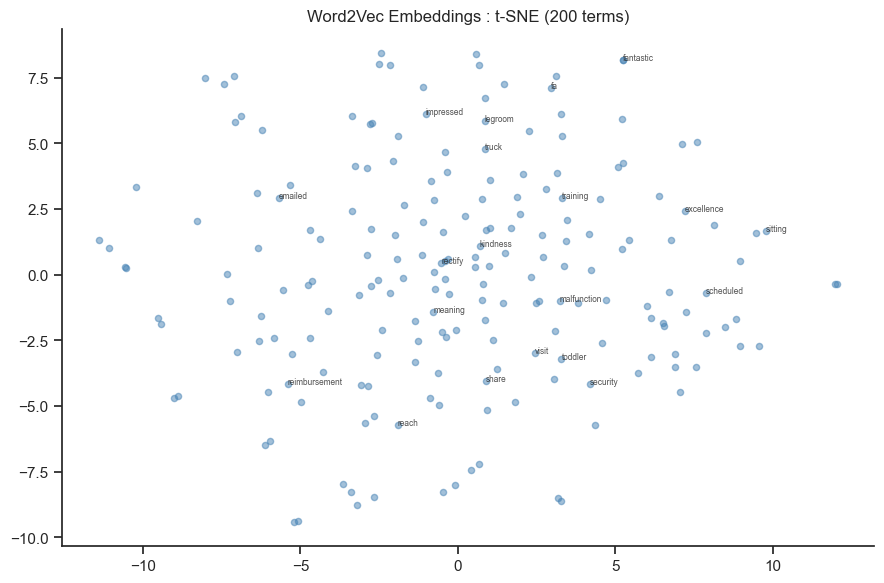

In [21]:
N_TSNE   = min(200, len(VOCAB_W2V))
samp_w2v = VOCAB_W2V.sample(N_TSNE, random_state=42)

tsne   = TSNE(n_components=2, random_state=42, perplexity=20, max_iter=1000  , learning_rate='auto', init='pca')
coords = tsne.fit_transform(samp_w2v.values)

tsne_df = pd.DataFrame(coords, index=samp_w2v.index, columns=['x','y'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(tsne_df['x'], tsne_df['y'], alpha=0.5, s=20, color='steelblue')
for term in tsne_df.sample(20, random_state=1).index:
    ax.annotate(term, (tsne_df.loc[term,'x'], tsne_df.loc[term,'y']), fontsize=6, alpha=0.8)
ax.set_title(f'Word2Vec Embeddings : t-SNE ({N_TSNE} terms)')
sns.despine()
plt.tight_layout()
plt.savefig('w2v_tsne.png', dpi=120, bbox_inches='tight')
plt.show()

## Riffs

### Riff 1 : Topic Heatmap: Mean LDA Weight per Airline

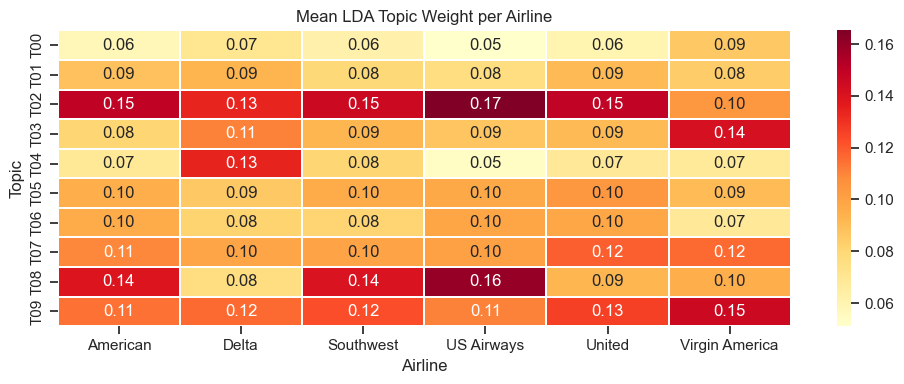

In [30]:
theta_airline = THETA.reset_index()
theta_airline['airline'] = theta_airline['airline_num'].map(airline_map)

riff1 = theta_airline.groupby('airline')[[f'T{i:02d}' for i in range(N_TOPICS)]].mean()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(riff1.T, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Mean LDA Topic Weight per Airline')
ax.set_xlabel('Airline'); ax.set_ylabel('Topic')
plt.tight_layout()
plt.savefig('riff1_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### Riff 2 : Sentiment vs Retweet Count

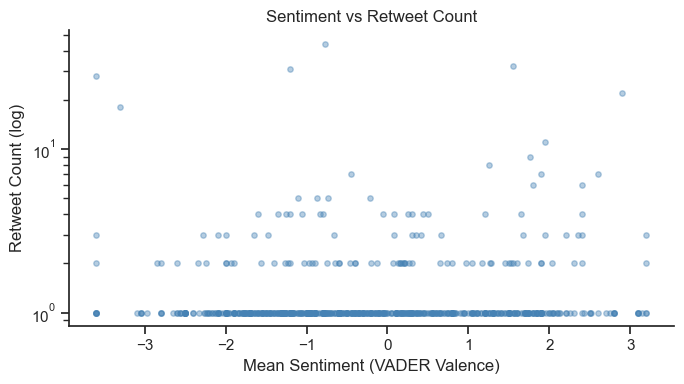

In [31]:
rt_meta = airline_raw[['airline_num','day_num','tweet_num','retweet_count']].drop_duplicates()
riff2   = DOC_SENT.merge(rt_meta, on=['airline_num','day_num','tweet_num'], how='left')
riff2   = riff2[riff2['retweet_count'] > 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(riff2['mean_sentiment'], riff2['retweet_count'],
           alpha=0.4, s=15, color='steelblue')
ax.set_yscale('log')
ax.set_xlabel('Mean Sentiment (VADER Valence)')
ax.set_ylabel('Retweet Count (log)')
ax.set_title('Sentiment vs Retweet Count')
sns.despine()
plt.tight_layout()
plt.savefig('riff2_sentiment_rt.png', dpi=120, bbox_inches='tight')
plt.show()

### Riff 3 : Sentiment over Day of Week

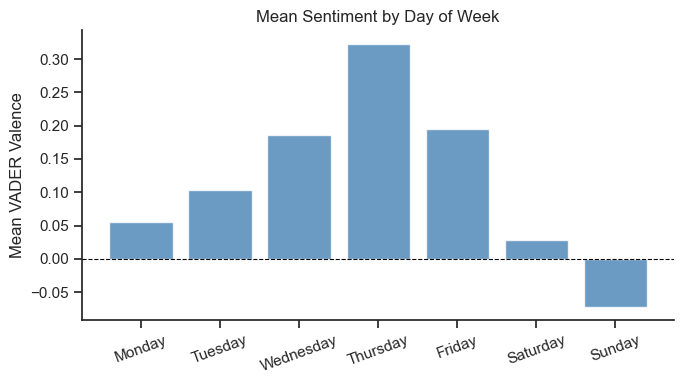

In [32]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
riff3 = sent_full.copy()
riff3['day_name'] = pd.Categorical(riff3['day_name'], categories=day_order, ordered=True)

day_sent = riff3.groupby('day_name', observed=True)['mean_sentiment'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(day_sent.index, day_sent.values, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Mean Sentiment by Day of Week')
ax.set_ylabel('Mean VADER Valence')
ax.tick_params(axis='x', rotation=20)
sns.despine()
plt.tight_layout()
plt.savefig('riff3_day_sentiment.png', dpi=120, bbox_inches='tight')
plt.show()

We can see there is quite a bit of a difference in the mean sentiment across the days, however we do not have enough data to give a true representation. However, from this data we can see that Thursdays seems to be the day with most positive tweets whereas Sundays seem to have the most negative tweets. Weekeds tend to have more negative tweets than weekdays with the starting of the week having relatively lower positive tweets